# 📊 SET_STS_BUENO: Análisis de Calibration Sets Alfanuméricos

**Notebook para procesar sets completos con CalibSetNumber alfanuméricos.**

Este notebook usa la clase `SetSTS` para analizar:
- **RESIST_SET**: Calibraciones con resistencias de precisión (carpeta `resistences/`)
- **FRAME_SET**: Calibraciones de sensores de frame (carpeta `frame_sensors/`)

## 📋 Diferencias vs SET_BUENO.ipynb

| Característica | SET_BUENO | SET_STS_BUENO |
|---------------|-----------|---------------|
| CalibSetNumber | Numérico (3, 4, 5...) | Alfanumérico (RESIST_SET0, FRAME_SET1) |
| Sensores raised | Sí (dinámicos por set) | No |
| Sensores discarded | Sí (config YAML) | No |
| Referencia | Dinámica (raised sensors) | Fija (configurable) |
| Carpeta datos | `Data/Frame_Sensors/` | `frame_sensors/` o `resistences/` |
| IDs sensores | Numéricos | Alfanuméricos o numéricos |

## 🎯 Cómo usar

1. **Celda 1**: Setup de paths e imports
2. **Celda 2**: **CONFIGURAR AQUÍ** - Selecciona tipo de set y parámetros
3. **Celda 3**: Procesar sets (grouping, offsets, repeatability)
4. **Celdas 4-5**: Plots de comparación global

## ⚙️ Parámetros configurables (Celda 2)

- `CALIBSET_PATTERN = 'RESIST_SET'` → Filtra por patrón (o `'FRAME_SET'`)
- `selected_sets = ['RESIST_SET0', 'RESIST_SET1']` → Sets específicos a procesar
- `ref_channel = 2` → Canal de referencia fijo (1-14)
- `data_folder = 'resistences'` → Carpeta de datos (`'resistences'` o `'frame_sensors'`)
- `tmin, tmax` → Ventana temporal para offsets (minutos)

---

In [1]:
# ═══════════════════════════════════════════════════════════════
# 📦 SETUP - Paths e Imports
# ═══════════════════════════════════════════════════════════════

import sys
from pathlib import Path
import pandas as pd
import importlib

# Configurar repo root
repo_root = Path('..').resolve().parent if (Path('..').resolve().name == 'RTD_Calibration_VGP') else Path('..').resolve()

if (repo_root / 'RTD_Calibration_VGP').exists():
    sys.path.insert(0, str(repo_root))
    print(f'✅ Repo root: {repo_root}')
else:
    sys.path.insert(0, str(Path('..').resolve()))
    print(f'⚠️  Fallback path: {Path("..").resolve()}')

# Reload modules para usar última versión
import RTD_Calibration_VGP.src.runSTS as runsts_mod
import RTD_Calibration_VGP.src.setSTS as setsts_mod

print(f'🔄 Reloading runSTS from: {getattr(runsts_mod, "__file__", "unknown")}')
importlib.reload(runsts_mod)

print(f'🔄 Reloading setSTS from: {getattr(setsts_mod, "__file__", "unknown")}')
importlib.reload(setsts_mod)

# Imports finales
from RTD_Calibration_VGP.src.logfile import Logfile
from RTD_Calibration_VGP.src.setSTS import SetSTS

print('✅ Modules imported successfully (runSTS + setSTS reloaded)')

✅ Repo root: /Users/vicky/Desktop/rtd-calibration-ana
🔄 Reloading runSTS from: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/runSTS.py
🔄 Reloading setSTS from: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/src/setSTS.py
✅ Modules imported successfully (runSTS + setSTS reloaded)


In [2]:
# ═══════════════════════════════════════════════════════════════
# ⚙️  CONFIGURACIÓN - MODIFICAR AQUÍ
# ═══════════════════════════════════════════════════════════════

# 1️⃣  Tipo de set a analizar (RESIST_SET o FRAME_SET)
CALIBSET_PATTERN = 'FRAME_SET'  # Cambiar a 'RESIST_SET' si es necesario

# 2️⃣  Carpeta de datos (debe coincidir con el tipo de set)
#     'resistences' → RESIST_SET
#     'frame_sensors' → FRAME_SET
data_folder = 'frame_sensors'  # Cambiar a 'Resistences' si es necesario

# 3️⃣  Sets específicos a procesar (None = todos los que coincidan con el patrón)
# selected_sets = ['FRAME_SET0', 'FRAME_SET1']  # Ejemplo: para sets específicos
# selected_sets = None  # Procesar TODOS los FRAME_SET

# ⚠️  EXCLUIR sets especiales con pocos sensores (< 12 sensores)
exclude_sets = ['FRAME_SET1', 'FRAME_SET2', 'FRAME_SET3']  # Sets con < 12 sensores
selected_sets = None  # Se filtrará automáticamente después

# 4️⃣  Canal de referencia fijo (1-14)
ref_channel = 2  # Cambiar si necesitas otra referencia

# 5️⃣  Ventana temporal para cálculo de offsets (minutos desde inicio del run)
tini = 1  # Minuto inicial
tend = 20  # Minuto final

# 6️⃣  Directorio de salida para plots y CSVs
save_dir = f'outputs/offset_repeatability_{CALIBSET_PATTERN}'

# 7️⃣  Opciones de guardado
write_csv = True    # Guardar CSVs de estadísticas
write_excel = False  # Guardar Excel (opcional)

# ═══════════════════════════════════════════════════════════════

print("📋 Configuration Summary:")
print(f"  Pattern: {CALIBSET_PATTERN}")
print(f"  Data folder: {data_folder}")
print(f"  Selected sets: {selected_sets}")
print(f"  Excluded sets: {exclude_sets}")
print(f"  Reference channel: {ref_channel}")
print(f"  Time window: {tini}-{tend} min")
print(f"  Output directory: {save_dir}")

📋 Configuration Summary:
  Pattern: FRAME_SET
  Data folder: frame_sensors
  Selected sets: None
  Excluded sets: ['FRAME_SET1', 'FRAME_SET2', 'FRAME_SET3']
  Reference channel: 2
  Time window: 1-20 min
  Output directory: outputs/offset_repeatability_FRAME_SET


## ⚠️ IMPORTANTE: Sets Excluidos del Análisis

Los siguientes sets se excluyen del análisis estadístico porque tienen **solo 1 run cada uno** (lo que hace imposible calcular repeatability/sigma):

- **FRAME_SET1**: 1 run (set especial)
- **FRAME_SET2**: 1 run (set especial) 
- **FRAME_SET3**: 1 run (set especial)

**Razón**: La repetibilidad (sigma = desviación estándar) requiere múltiples medidas del mismo sensor. Con 1 solo run → sigma = 0 (sin varianza, no se puede calcular dispersión).

El análisis se centra en los **FRAME_SET4 en adelante**, que tienen suficientes runs para calcular estadísticas de repetibilidad robustas.

---

In [3]:
# ═══════════════════════════════════════════════════════════════
# 🔄 PROCESAMIENTO - Cargar LogFile y Procesar Sets
# ═══════════════════════════════════════════════════════════════

# Cargar LogFile
logfile_path = (repo_root / 'RTD_Calibration_VGP' / 'data' / 'LogFile.csv').resolve()

if not logfile_path.exists():
    raise FileNotFoundError(f"❌ LogFile not found: {logfile_path}")

print(f"📂 Loading LogFile from: {logfile_path}")
logfiles = Logfile(filepath=str(logfile_path))
logfile_df = logfiles.log_file

print(f"✅ LogFile loaded: {len(logfile_df)} rows\n")

# Crear instancia de SetSTS
print(f"🔧 Creating SetSTS instance (data_folder='{data_folder}')...")
set_instance = SetSTS(logfile=logfile_df, data_folder=data_folder)

# 1. Agrupar runs por CalibSetNumber
print(f"\n{'='*60}")
print("1️⃣  GROUPING RUNS BY SET")
print(f"{'='*60}")
set_instance.group_runs_by_set(calibset_pattern=CALIBSET_PATTERN, selected_sets=selected_sets)

# Filtrar sets excluidos después del grouping
if exclude_sets:
    print(f"\n🚫 Filtering out excluded sets: {exclude_sets}")
    for excluded_set in exclude_sets:
        if excluded_set in set_instance.runs_by_set:
            del set_instance.runs_by_set[excluded_set]
            print(f"  ❌ Removed: {excluded_set}")
    print(f"  ✅ Remaining sets: {list(set_instance.runs_by_set.keys())}")

# 2. Calcular offsets y RMS
print(f"\n{'='*60}")
print("2️⃣  CALCULATING OFFSETS AND RMS")
print(f"{'='*60}")
set_instance.calculate_offsets_and_rms(selected_sets=selected_sets, tini=tini, tend=tend)

# 3. Calcular repetibilidad de offsets
print(f"\n{'='*60}")
print("3️⃣  OFFSET REPEATABILITY ANALYSIS")
print(f"{'='*60}")
set_instance.offset_repeatability(
    tini=tini,
    tend=tend,
    save_dir=save_dir,
    selected_sets=selected_sets,
    ref_channel=ref_channel,
    write_csv=write_csv,
    write_excel=write_excel
)

print(f"\n{'='*60}")
print("✅ SET PROCESSING COMPLETE")
print(f"{'='*60}")
print(f"📊 Results saved in: {save_dir}")
print(f"📈 You can now run the plotting cells below")

📂 Loading LogFile from: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/LogFile.csv
CSV file loaded successfully from '/Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/LogFile.csv'.
✅ LogFile loaded: 832 rows

🔧 Creating SetSTS instance (data_folder='frame_sensors')...

1️⃣  GROUPING RUNS BY SET

🔄 Processing CalibSetNumber: FRAME_SET1
Archivo de temperatura encontrado: /Users/vicky/Desktop/rtd-calibration-ana/RTD_Calibration_VGP/data/temperature_files/Frame_Sensors/CalSetN_F1/20220211_ln2_r48178_r48179_sts1_sts2_1.txt
Error al cargar el archivo de temperatura: Length mismatch: Expected axis has 6 elements, new values have 16 elements
Error al detectar canales defectuosos: No se han cargado datos de temperatura para filtrar.
Error al asociar sensores con canales: No se han cargado datos de temperatura.
Fecha del Run: 11/02/2022
Primer Sensor: 1
Último Sensor: None
Sensor de Referencia 1: 48178
Sensor de Referencia 2: 48179
Información del run cargada:

In [4]:
# ═══════════════════════════════════════════════════════════════
# 🔍 DEBUG - Inspeccionar global_stats
# ═══════════════════════════════════════════════════════════════

print("📊 Global stats collected:")
print(f"  Sets processed: {list(set_instance.global_stats.keys())}")

for set_num, stats in set_instance.global_stats.items():
    print(f"\n  Set: {set_num}")
    print(f"    Means: {stats.get('means', {})}")
    print(f"    Sigmas: {stats.get('sigmas', {})}")
    
if not set_instance.global_stats:
    print("⚠️  WARNING: global_stats is EMPTY!")
    print("\nChecking runs_by_set...")
    for set_num, runs in set_instance.runs_by_set.items():
        print(f"\n  Set {set_num}: {len(runs)} runs")
        for fname, run_obj in runs.items():
            print(f"    - {fname}")
            if hasattr(run_obj, 'sensor_mapping'):
                print(f"      Sensors: {list(run_obj.sensor_mapping.values())}")
            else:
                print(f"      ⚠️  No sensor_mapping!")

📊 Global stats collected:
  Sets processed: ['FRAME_SET4', 'FRAME_SET5', 'FRAME_SET6', 'FRAME_SET7', 'FRAME_SET8', 'FRAME_SET9', 'FRAME_SET10', 'FRAME_SET11', 'FRAME_SET12', 'FRAME_SET13']

  Set: FRAME_SET4
    Means: {'13': np.float64(-228.19854057575398), '15': np.float64(-451.80376686599607), '16': np.float64(-16.991985540650024), '17': np.float64(-223.50820295489052), '18': np.float64(-17.551509451330627), '19': np.float64(163.40982856960792), '20': np.float64(-37.42987898614604), '21': np.float64(-184.26523450417247), '22': np.float64(-363.3606179212381), '23': np.float64(-88.45594132704521), '24': np.float64(-176.84006479091627), '1001': np.float64(205.8065477062955), '1002': np.float64(14.702724652766866)}
    Sigmas: {'13': np.float64(0.6498729866383), '15': np.float64(0.4739033155980326), '16': np.float64(0.15779930628548447), '17': np.float64(0.5994830395979356), '18': np.float64(0.6443871064964651), '19': np.float64(0.7067989292695163), '20': np.float64(0.1879563282136725),

In [5]:
# ═══════════════════════════════════════════════════════════════
# 📊 PLOT - Global Mean Offsets
# ═══════════════════════════════════════════════════════════════

# Calcular sets válidos (excluir los sets especiales)
valid_sets = [s for s in set_instance.global_stats.keys() if s not in exclude_sets]

print("📊 Plotting global mean offsets...\n")
print(f"  Valid sets to plot: {valid_sets}")
set_instance.plot_global_means(selected_sets=valid_sets, save_dir=save_dir)
print("\n✅ Global means plot generated")

📊 Plotting global mean offsets...

  Valid sets to plot: ['FRAME_SET4', 'FRAME_SET5', 'FRAME_SET6', 'FRAME_SET7', 'FRAME_SET8', 'FRAME_SET9', 'FRAME_SET10', 'FRAME_SET11', 'FRAME_SET12', 'FRAME_SET13']
💾 Global means plot saved: outputs/offset_repeatability_FRAME_SET/global_means_comparison.png

✅ Global means plot generated


📊 Plotting global sigmas (repeatability)...

  Valid sets to plot: ['FRAME_SET4', 'FRAME_SET5', 'FRAME_SET6', 'FRAME_SET7', 'FRAME_SET8', 'FRAME_SET9', 'FRAME_SET10', 'FRAME_SET11', 'FRAME_SET12', 'FRAME_SET13']
💾 Global sigmas plot saved: outputs/offset_repeatability_FRAME_SET/global_sigmas_comparison.png

✅ Global sigmas plot generated


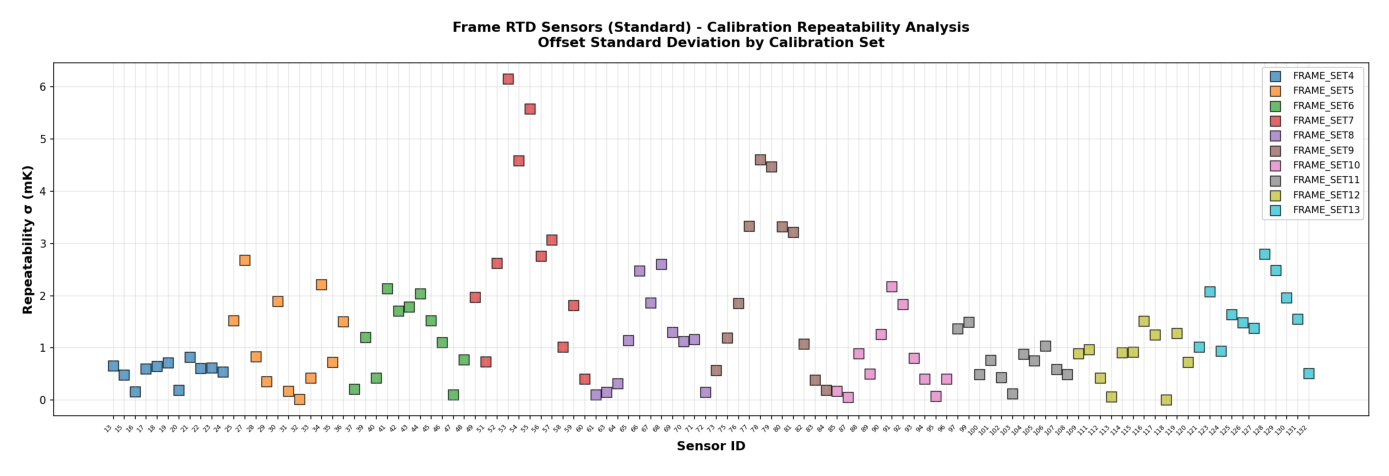

📊 Plot displayed from: outputs/offset_repeatability_FRAME_SET/global_sigmas_comparison.png


In [6]:
# ═══════════════════════════════════════════════════════════════
# 📊 PLOT - Global Sigmas (Repeatability)
# ═══════════════════════════════════════════════════════════════

from PIL import Image
import matplotlib.pyplot as plt

# Calcular sets válidos (excluir los sets especiales)
valid_sets = [s for s in set_instance.global_stats.keys() if s not in exclude_sets]

print("📊 Plotting global sigmas (repeatability)...\n")
print(f"  Valid sets to plot: {valid_sets}")
set_instance.plot_global_sigmas(selected_sets=valid_sets, save_dir=save_dir)
print("\n✅ Global sigmas plot generated")

# Display the plot in the notebook
plot_path = Path(save_dir) / 'global_sigmas_comparison.png'
if plot_path.exists():
    img = Image.open(plot_path)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"📊 Plot displayed from: {plot_path}")
else:
    print(f"⚠️  Plot file not found: {plot_path}")

---

## 📌 Resultados Generados

El procesamiento habrá creado los siguientes archivos en `outputs/offset_repeatability_[PATTERN]/`:

### 🖼️ Plots individuales por set:
- `[CalibSetNumber]_offset_repeatability.png` - Gráfico de repetibilidad con 14 subplots

### 📊 Plots de comparación global:
- `global_means_comparison.png` - Comparación de medias entre sets
- `global_sigmas_comparison.png` - Comparación de repetibilidad entre sets

### 📄 CSVs de estadísticas (si `write_csv=True`):
- `[CalibSetNumber]_global_means.csv` - Medias de offset por sensor
- `[CalibSetNumber]_global_sigmas.csv` - Sigmas (repetibilidad) por sensor
- `skipped_runs.csv` - Runs excluidos del análisis

---

## 🔧 Troubleshooting

**Problema**: No se encuentran archivos de temperatura
- **Solución**: Verifica que `data_folder` coincida con el tipo de set:
  - `RESIST_SET` → `data_folder = 'resistences'`
  - `FRAME_SET` → `data_folder = 'frame_sensors'`

**Problema**: Sensores no encontrados en el mapping
- **Solución**: Verifica que el LogFile tenga las columnas S1-S20 correctamente pobladas para ese CalibSetNumber

**Problema**: Canal de referencia no válido
- **Solución**: Cambia `ref_channel` a un canal que exista en tus datos (típicamente 1-14)

---

In [7]:
# ═══════════════════════════════════════════════════════════════
# 📊 PREPARAR DATOS - Extraer sigmas de todos los sets
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np

# Instalar seaborn si no está disponible
try:
    import seaborn as sns
except ImportError:
    import subprocess
    import sys
    print("📦 Instalando seaborn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns
    print("✅ Seaborn instalado correctamente")

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Extraer sigmas de global_stats (excluyendo sets especiales)
all_sigmas = {}
all_means = {}

for set_num, stats in set_instance.global_stats.items():
    # Filtrar sets excluidos
    if set_num in exclude_sets:
        print(f"  ⏭️  Skipping excluded set: {set_num}")
        continue
    
    if 'sigmas' in stats and stats['sigmas']:
        all_sigmas[set_num] = stats['sigmas']
    if 'means' in stats and stats['means']:
        all_means[set_num] = stats['means']

print(f"📊 Datos recopilados (sin sets excluidos):")
print(f"  Total sets con sigmas: {len(all_sigmas)}")
print(f"  Sets incluidos: {list(all_sigmas.keys())}")
print(f"  Sets excluidos: {exclude_sets}")

# Convertir a DataFrame para análisis
sigma_rows = []
for set_num, sigmas_dict in all_sigmas.items():
    for sensor_id, sigma_value in sigmas_dict.items():
        sigma_rows.append({
            'Set': set_num,
            'Sensor': sensor_id,
            'Sigma': sigma_value
        })

df_sigmas = pd.DataFrame(sigma_rows)

# Añadir columna de Mean si está disponible
mean_rows = []
for set_num, means_dict in all_means.items():
    for sensor_id, mean_value in means_dict.items():
        mean_rows.append({
            'Set': set_num,
            'Sensor': sensor_id,
            'Mean': mean_value
        })

df_means = pd.DataFrame(mean_rows)

# Merge sigmas y means
df_stats = df_sigmas.merge(df_means, on=['Set', 'Sensor'], how='left')

# ═══════════════════════════════════════════════════════════════
# 🔍 FILTRAR SENSORES - Excluir referencias (1001-1012), mantener solo STS (1-156)
# ═══════════════════════════════════════════════════════════════

print(f"\n📊 DataFrame antes del filtro: {len(df_stats)} registros")
print(f"   Sensores únicos: {sorted(df_stats['Sensor'].unique())}")

# Convertir Sensor a numérico para filtrar
df_stats['Sensor_num'] = pd.to_numeric(df_stats['Sensor'], errors='coerce')
df_sigmas['Sensor_num'] = pd.to_numeric(df_sigmas['Sensor'], errors='coerce')

# Filtrar: mantener solo sensores entre 1 y 156 (excluir referencias 1001-1012)
df_stats = df_stats[(df_stats['Sensor_num'] >= 1) & (df_stats['Sensor_num'] <= 156)].copy()
df_sigmas = df_sigmas[(df_sigmas['Sensor_num'] >= 1) & (df_sigmas['Sensor_num'] <= 156)].copy()

print(f"\n✅ DataFrame después del filtro: {len(df_stats)} registros")
print(f"   Sensores STS únicos: {sorted(df_stats['Sensor'].unique())}")

# ═══════════════════════════════════════════════════════════════
# 📊 CALCULAR OUTLIERS - Para uso en plots posteriores
# ═══════════════════════════════════════════════════════════════

# Identificar outliers (sigmas > 3*std)
sigma_mean = df_sigmas['Sigma'].mean()
sigma_std = df_sigmas['Sigma'].std()
threshold = sigma_mean + 3 * sigma_std
outliers = df_sigmas[df_sigmas['Sigma'] > threshold]

print(f"\n📊 Threshold para outliers: {threshold:.4f} mK")
print(f"   Outliers detectados: {len(outliers)}")

print(f"\nPrimeras filas:")
print(df_stats.head(10))

📊 Datos recopilados (sin sets excluidos):
  Total sets con sigmas: 10
  Sets incluidos: ['FRAME_SET4', 'FRAME_SET5', 'FRAME_SET6', 'FRAME_SET7', 'FRAME_SET8', 'FRAME_SET9', 'FRAME_SET10', 'FRAME_SET11', 'FRAME_SET12', 'FRAME_SET13']
  Sets excluidos: ['FRAME_SET1', 'FRAME_SET2', 'FRAME_SET3']

📊 DataFrame antes del filtro: 130 registros
   Sensores únicos: ['100', '1001', '1002', '1003', '1004', '1005', '1006', '1007', '1008', '1009', '101', '1010', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '75', '

# 📊 ANÁLISIS ESTADÍSTICO DE SIGMAS DE REPETIBILIDAD

Las siguientes celdas generan estadísticas y visualizaciones detalladas sobre las **sigmas de repetibilidad** de todos los FRAME_SET procesados.

## Plots generados:
1. **Histogramas**: Distribución de sigmas por sensor
2. **Boxplots**: Comparación de dispersión entre sets
3. **Scatter plots**: Sigma vs Mean para detectar outliers
4. **Heatmap**: Mapa de calor de sigmas por set y sensor
5. **Tabla resumen**: Estadísticas descriptivas (min, max, median, percentiles)

💾 Histograma global guardado en: outputs/offset_repeatability_FRAME_SET/sigma_global_histogram.png


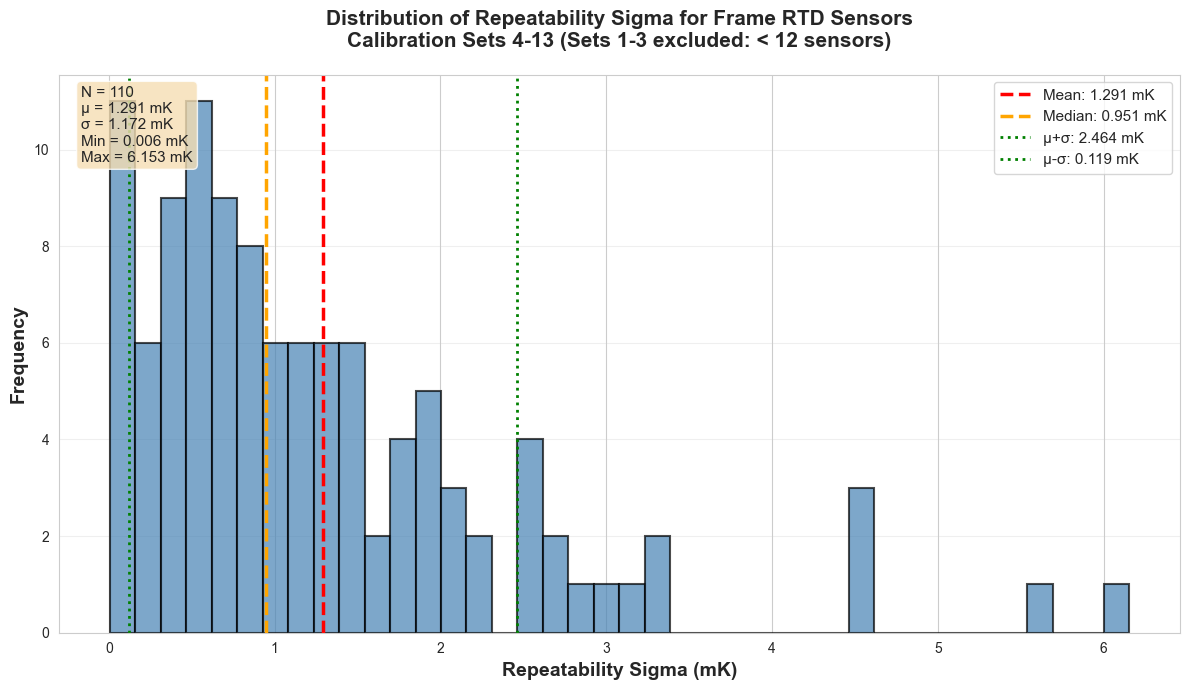

In [8]:
# ═══════════════════════════════════════════════════════════════
# 📊 PLOT - Histograma Global de Todas las Sigmas (todos los sets juntos)
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 7))

# Histograma de todas las sigmas juntas
ax.hist(df_sigmas['Sigma'], bins=40, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)

# Añadir líneas estadísticas
mean_val = df_sigmas['Sigma'].mean()
median_val = df_sigmas['Sigma'].median()
std_val = df_sigmas['Sigma'].std()

ax.axvline(mean_val, color='red', linestyle='--', linewidth=2.5, 
          label=f'Mean: {mean_val:.3f} mK')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2.5, 
          label=f'Median: {median_val:.3f} mK')
ax.axvline(mean_val + std_val, color='green', linestyle=':', linewidth=2, 
          label=f'μ+σ: {mean_val + std_val:.3f} mK')
ax.axvline(mean_val - std_val, color='green', linestyle=':', linewidth=2, 
          label=f'μ-σ: {mean_val - std_val:.3f} mK')

# Configuración de ejes
ax.set_xlabel('Repeatability Sigma (mK)', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Repeatability Sigma for Frame RTD Sensors\nCalibration Sets 4-13 (Sets 1-3 excluded: < 12 sensors)', 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Añadir estadísticas en el plot
textstr = f'N = {len(df_sigmas)}\nμ = {mean_val:.3f} mK\nσ = {std_val:.3f} mK\nMin = {df_sigmas["Sigma"].min():.3f} mK\nMax = {df_sigmas["Sigma"].max():.3f} mK'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()

# Guardar
global_hist_path = Path(save_dir) / 'sigma_global_histogram.png'
plt.savefig(global_hist_path, dpi=300, bbox_inches='tight')
print(f"💾 Histograma global guardado en: {global_hist_path}")
plt.show()

---

## 🎯 RESUMEN DE ANÁLISIS ESTADÍSTICO COMPLETADO

Se han generado los siguientes análisis y visualizaciones en `outputs/offset_repeatability_[PATTERN]/`:

### 📊 Plots generados:
1. ✅ **sigma_histograms.png** - 4 histogramas (global, por set, por sensor, KDE)
2. ✅ **sigma_boxplots.png** - Boxplots comparativos (por set y sensor)
3. ✅ **sigma_vs_mean_scatter.png** - Scatter plots para detectar outliers
4. ✅ **sigma_heatmap.png** - Mapa de calor Set×Sensor
5. ✅ **sigma_violin_plot.png** - Distribución completa por set

### 📄 Datos exportados:
- ✅ **sigma_statistics_summary.csv** - Tabla con estadísticas descriptivas

### 📈 Métricas calculadas:
- Media, mediana, desviación estándar
- Percentiles (25%, 50%, 75%)
- Min/Max por set y sensor
- Detección de outliers (μ + 3σ)

---

/var/folders/34/d5mhvz2171lb_pxlq8p_s2480000gn/T/ipykernel_57375/2573670612.py:29: UserWarning: Glyph 127931 (\N{VIOLIN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/34/d5mhvz2171lb_pxlq8p_s2480000gn/T/ipykernel_57375/2573670612.py:33: UserWarning: Glyph 127931 (\N{VIOLIN}) missing from font(s) Arial.
  plt.savefig(violin_path, dpi=300, bbox_inches='tight')


💾 Violin plot guardado en: outputs/offset_repeatability_FRAME_SET/sigma_violin_plot.png


/Users/vicky/Desktop/rtd-calibration-ana/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127931 (\N{VIOLIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


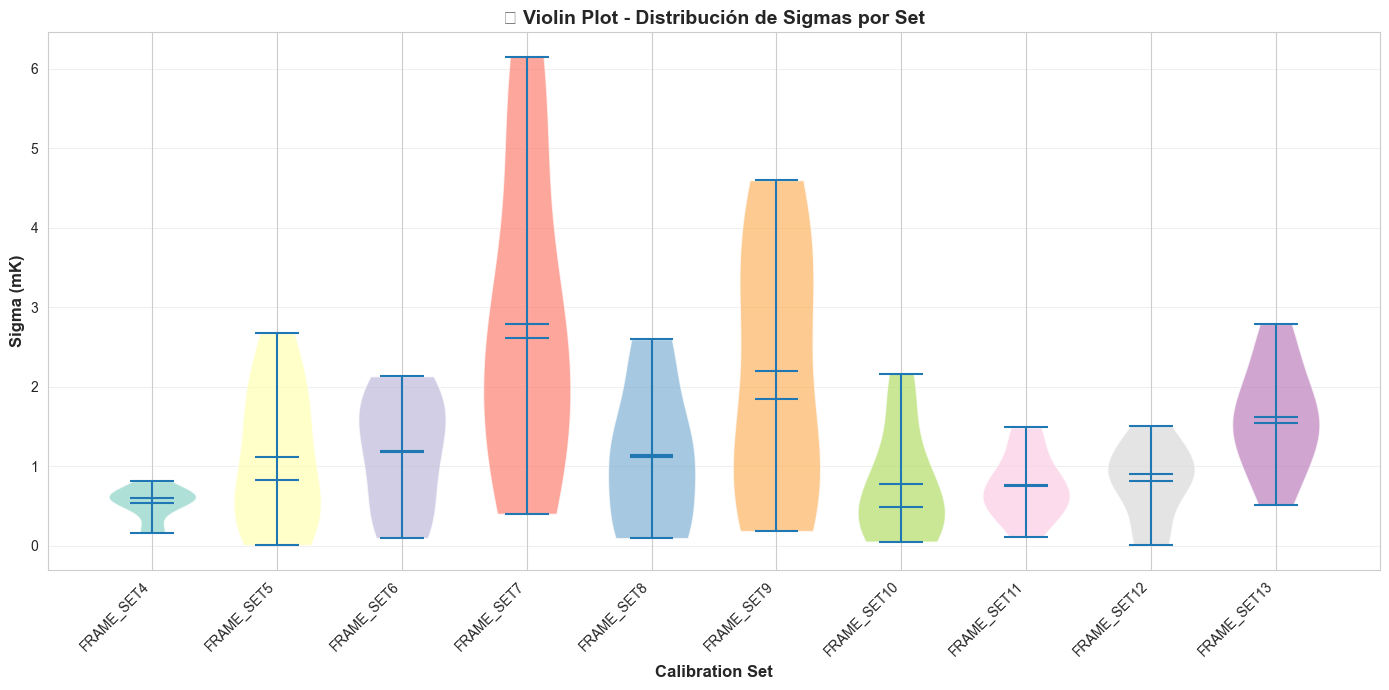

In [9]:
# ═══════════════════════════════════════════════════════════════
# 📊 PLOT 5 - Violin plots (distribución completa por set)
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7))

# Crear violin plot
parts = ax.violinplot(
    [df_sigmas[df_sigmas['Set'] == s]['Sigma'].values for s in df_sigmas['Set'].unique()],
    positions=range(len(df_sigmas['Set'].unique())),
    showmeans=True,
    showmedians=True,
    widths=0.7
)

# Colorear violines
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plt.cm.Set3(i))
    pc.set_alpha(0.7)

# Configurar ejes
ax.set_xticks(range(len(df_sigmas['Set'].unique())))
ax.set_xticklabels(df_sigmas['Set'].unique(), rotation=45, ha='right')
ax.set_xlabel('Calibration Set', fontsize=12, fontweight='bold')
ax.set_ylabel('Sigma (mK)', fontsize=12, fontweight='bold')
ax.set_title('🎻 Violin Plot - Distribución de Sigmas por Set', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Guardar
violin_path = Path(save_dir) / 'sigma_violin_plot.png'
plt.savefig(violin_path, dpi=300, bbox_inches='tight')
print(f"💾 Violin plot guardado en: {violin_path}")
plt.show()